# 01 · Exploración de bases de datos (Fase 1)

**Curso:** Análisis de Datos · ITM · 2026-2 · Docente: Daniel Alexis Nieto Mora

Se exploran **3 bases de datos de 3 tipos distintos** (tabular, imágenes y texto). Para cada una se documenta fuente y tipo, características básicas, nivel de documentación y posibles aplicaciones. Al final se comparan con criterios de **completitud, relevancia, documentación y manejabilidad** y se elige la base final.

| # | Base | Tipo de dato | Origen |
|---|------|--------------|--------|
| 1 | NYC Taxi Trips (marzo 2019) | Tabular (numérico, categórico, fecha-hora) | NYC TLC, subconjunto curado en `seaborn-data` |
| 2 | Optical Recognition of Handwritten Digits | Imágenes 8×8 en escala de grises | UCI ML Repository, incluido en `scikit-learn` |
| 3 | SMS Spam Collection | Texto corto etiquetado | UCI ML Repository (Almeida & Hidalgo, 2011) |

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from src.utils import RAW, guardar_fig

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

def resumen(nombre, df, archivo=None):
    """Ficha rápida de una base: registros, atributos, faltantes y tamaño."""
    return {
        "base": nombre,
        "registros": df.shape[0],
        "atributos": df.shape[1],
        "% celdas faltantes": round(df.isna().mean().mean() * 100, 2),
        "memoria (MB)": round(df.memory_usage(deep=True).sum() / 1e6, 2),
        "disco (MB)": round(os.path.getsize(archivo) / 1e6, 2) if archivo else None,
    }

## 1. NYC Taxi Trips — tabular

- **Fuente:** registros de viajes de la *NYC Taxi & Limousine Commission (TLC)*, marzo de 2019. Se usa el subconjunto de 6.433 viajes publicado en el repositorio `mwaskom/seaborn-data`.
- **Tipo de fuente:** **secundaria** (datos recolectados por la TLC con fines regulatorios, reutilizados aquí para análisis).
- **Documentación:** alta. La TLC publica diccionario de datos y descripción de zonas; los nombres de columnas son autoexplicativos.
- **Aplicaciones:** predicción de tarifa o propina, análisis de demanda por hora y zona, detección de registros anómalos, segmentación de viajes.

In [2]:
taxis = pd.read_csv(RAW / "taxis.csv", parse_dates=["pickup", "dropoff"])
display(taxis.head())
taxis.info()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [3]:
print("Tipos de variables:")
print(taxis.dtypes.value_counts())
print("\nFaltantes por columna:")
print(taxis.isna().sum()[taxis.isna().sum() > 0])

Tipos de variables:
str               6
float64           5
datetime64[us]    2
int64             1
Name: count, dtype: int64

Faltantes por columna:
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


## 2. Handwritten Digits — imágenes

- **Fuente:** *Optical Recognition of Handwritten Digits* (UCI ML Repository). Formularios escritos por 43 personas, escaneados y reducidos a matrices 8×8. Viene incluido en `scikit-learn` (`load_digits`).
- **Tipo de fuente:** **secundaria**.
- **Documentación:** alta (ficha UCI + documentación de scikit-learn).
- **Aplicaciones:** clasificación de dígitos, prueba de reducción de dimensionalidad (PCA, t-SNE), OCR básico.

Imágenes: (1797, 8, 8) | rango de intensidad: 0.0 - 16.0


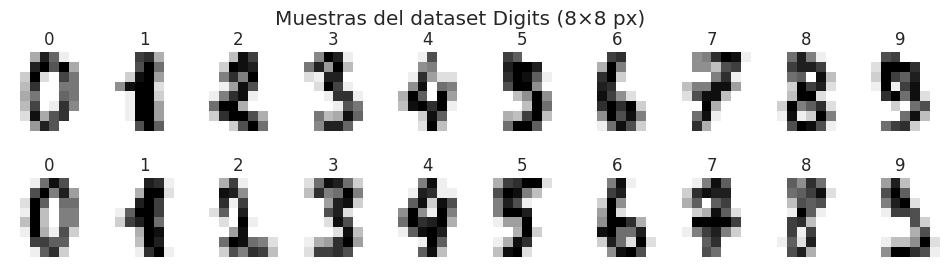

In [4]:
digits = load_digits()
df_digits = pd.DataFrame(digits.data, columns=digits.feature_names)
df_digits["target"] = digits.target
print("Imágenes:", digits.images.shape, "| rango de intensidad:", digits.data.min(), "-", digits.data.max())

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for ax, img, y in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(y); ax.axis("off")
plt.suptitle("Muestras del dataset Digits (8×8 px)")
guardar_fig("01_digits_muestras"); plt.show()

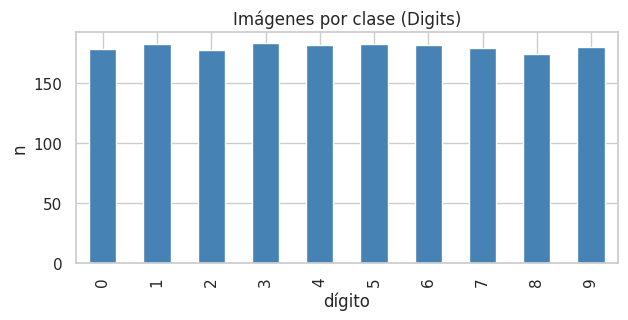

Píxeles con varianza cero (no aportan información): 3


In [5]:
ax = df_digits["target"].value_counts().sort_index().plot.bar(figsize=(7, 3), color="steelblue")
ax.set_title("Imágenes por clase (Digits)"); ax.set_xlabel("dígito"); ax.set_ylabel("n")
plt.show()
print("Píxeles con varianza cero (no aportan información):", (df_digits.drop(columns="target").var() == 0).sum())

## 3. SMS Spam Collection — texto

- **Fuente:** *SMS Spam Collection v.1* (UCI ML Repository; Almeida, Gómez Hidalgo & Yamakami, 2011). Copia tomada del repositorio `justmarkham/pycon-2016-tutorial`.
- **Tipo de fuente:** **secundaria** (mensajes recopilados de foros y corpus públicos).
- **Documentación:** media. La ficha de UCI describe origen y etiquetado, pero no hay metadatos por mensaje (fecha, operador, idioma).
- **Aplicaciones:** filtros antispam, clasificación de texto, análisis de vocabulario.

In [6]:
sms = pd.read_csv(RAW / "sms.tsv", sep="\t", header=None, names=["label", "message"])
sms["n_caracteres"] = sms["message"].str.len()
sms["n_palabras"] = sms["message"].str.split().str.len()
display(sms.head())
print(sms["label"].value_counts(normalize=True).round(3))
print("Mensajes duplicados:", sms.duplicated("message").sum())

,label,message,n_caracteres,n_palabras
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


label
ham     0.866
spam    0.134
Name: proportion, dtype: float64
Mensajes duplicados: 403


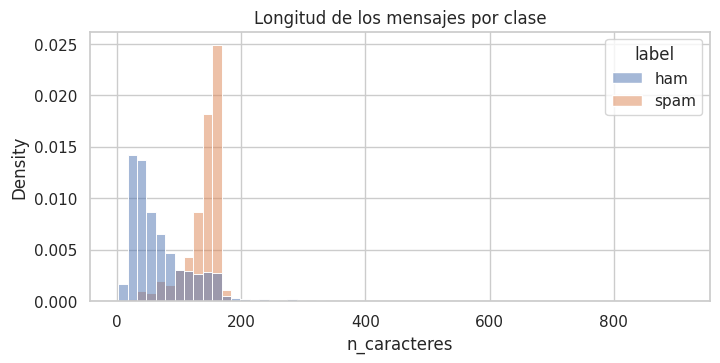

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(data=sms, x="n_caracteres", hue="label", bins=60, stat="density", common_norm=False, ax=ax)
ax.set_title("Longitud de los mensajes por clase")
guardar_fig("01_sms_longitud"); plt.show()

## 4. Comparación y selección

Resumen cuantitativo de las tres bases:

In [8]:
fichas = pd.DataFrame([
    resumen("NYC Taxis (tabular)", taxis, RAW / "taxis.csv"),
    resumen("Digits (imágenes)", df_digits),
    resumen("SMS Spam (texto)", sms.drop(columns=["n_caracteres", "n_palabras"]), RAW / "sms.tsv"),
]).set_index("base")
fichas

,registros,atributos,% celdas faltantes,memoria (MB),disco (MB)
base,,,,,
NYC Taxis (tabular),6433,14,0.21,2.71,0.87
Digits (imágenes),1797,65,0.00,0.93,NaN
SMS Spam (texto),5572,2,0.00,1.02,0.48


Matriz de decisión (escala 1–5, pesos definidos por el equipo). El criterio de **relevancia** se entiende como qué tanto permite la base cumplir lo pedido en el EDA: faltantes, outliers, distribuciones, variables numéricas y categóricas, relaciones y series de tiempo.

In [9]:
pesos = {"completitud": 0.20, "relevancia": 0.40, "documentación": 0.20, "manejabilidad": 0.20}
puntajes = pd.DataFrame({
    "NYC Taxis (tabular)": {"completitud": 4, "relevancia": 5, "documentación": 5, "manejabilidad": 5},
    "Digits (imágenes)":   {"completitud": 5, "relevancia": 2, "documentación": 5, "manejabilidad": 5},
    "SMS Spam (texto)":    {"completitud": 4, "relevancia": 2, "documentación": 3, "manejabilidad": 5},
}).T
puntajes["total ponderado"] = sum(puntajes[c] * w for c, w in pesos.items())
puntajes.sort_values("total ponderado", ascending=False)

,completitud,relevancia,documentación,manejabilidad,total ponderado
NYC Taxis (tabular),4,5,5,5,4.8
Digits (imágenes),5,2,5,5,3.8
SMS Spam (texto),4,2,3,5,3.2


### Justificación

- **Digits** es muy limpia (0 faltantes) y homogénea: 64 píxeles con la misma escala y una sola variable categórica. Sirve bien para reducción de dimensionalidad, pero deja sin material el análisis de faltantes, outliers, variables categóricas y series de tiempo.
- **SMS Spam** tiene una sola variable de texto y la etiqueta. Para hacer un EDA completo habría que construir casi todas las variables a mano; además tiene ~400 mensajes duplicados y poca metadata.
- **NYC Taxis** combina variables **numéricas** (distancia, tarifa, propina, peajes), **categóricas** (color, pago, zonas, municipios) y **fecha-hora**. Tiene **faltantes reales** (<1 %), **outliers** (viajes al aeropuerto, distancia 0) y **distribuciones sesgadas**, lo que permite ejercitar todas las técnicas pedidas. Su tamaño (6.433 × 14) es manejable y está bien documentada.

**Base seleccionada: NYC Taxi Trips (marzo 2019).**